In [1]:
import pandas as pd
import matplotlib.pyplot as plt

sba_data = pd.read_csv('7a Data.csv', low_memory=False)
print(sba_data.shape)
print(sba_data.head())

(114511, 41)
     asofdate  program   l2locid                             borrname  \
0  12/31/2025      504  188155.0                      Enviroplas, Inc   
1  12/31/2025      504  447141.0              Canyon Lake Auto Repair   
2  12/31/2025      504  188310.0      Doug Foley's Drag Racing School   
3  12/31/2025      504  188130.0  Nationwide Relocation Services Inc.   
4  12/31/2025      504  188138.0            Canyon View Building, LTD   

              borrstreet                        borrcity borrstate  borrzip  \
0      10100 Hedden Rd..                      Evansville        IN    47725   
1          13098 FM 306.       Canyon lake (canyon city)        TX    78133   
2          305 Pit Road.                     Mooresville        NC    28115   
3  2000 N. State Road 7.                   Pompano beach        FL    33063   
4    336 West 100 South.  Spanish fork (corporate name f        UT    84660   

                         cdc_name                 cdc_street  ...  \
0   

In [2]:
print(sba_data['naicsdescription'].value_counts().head(20))

naicsdescription
Full-Service Restaurants                                       6070
Hotels (except Casino Hotels) and Motels                       5098
Offices of Physicians (except Mental Health Specialists)       3311
Offices of Dentists                                            3013
Child Day Care Services                                        2900
Limited-Service Restaurants                                    2838
General Automotive Repair                                      2371
Offices of Lawyers                                             2199
All Other Specialty Trade Contractors                          1618
Car Washes                                                     1560
Plumbing, Heating, and Air-Conditioning Contractors            1391
Fitness and Recreational Sports Centers                        1350
Lessors of Miniwarehouses and Self-Storage Units               1318
Gasoline Stations with Convenience Stores                      1281
Automotive Body, Paint, and Int

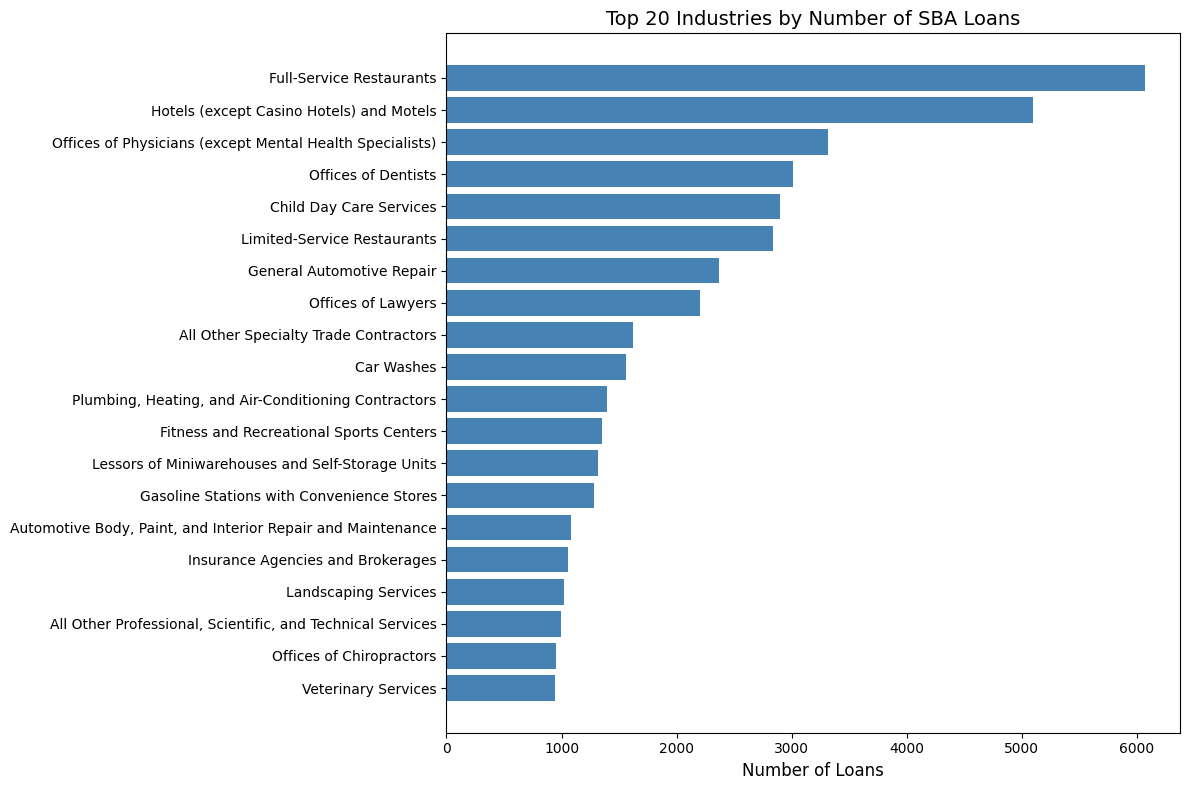

In [ ]:
top_industries = sba_data['naicsdescription'].value_counts().head(20)

plt.figure(figsize=(12, 8))
plt.barh(top_industries.index, top_industries.values, color='steelblue')
plt.title('Top 20 Industries by Number of SBA Loans (FY2020-Present)', fontsize=14)
plt.xlabel('Number of Loans', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

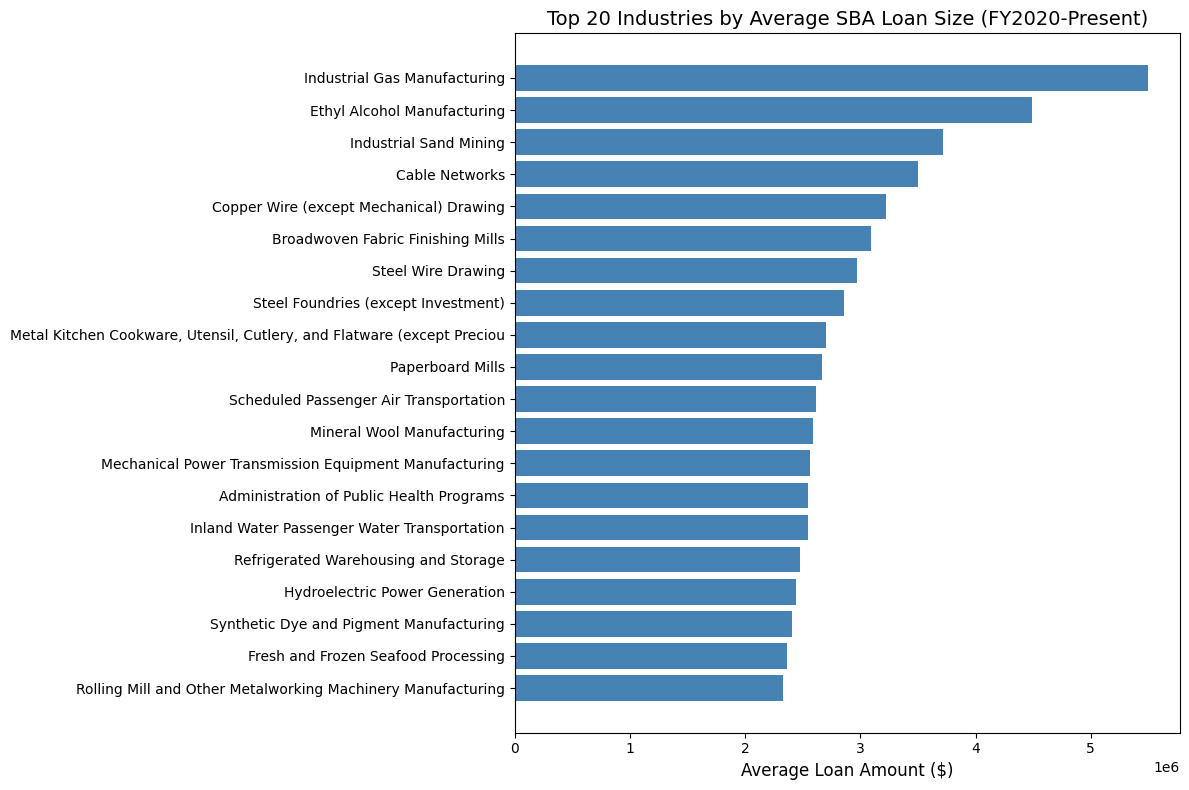

In [5]:
avg_loan_by_industry = sba_data.groupby('naicsdescription')['grossapproval'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.barh(avg_loan_by_industry.index, avg_loan_by_industry.values, color='steelblue')
plt.title('Top 20 Industries by Average SBA Loan Size (FY2020-Present)', fontsize=14)
plt.xlabel('Average Loan Amount ($)', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

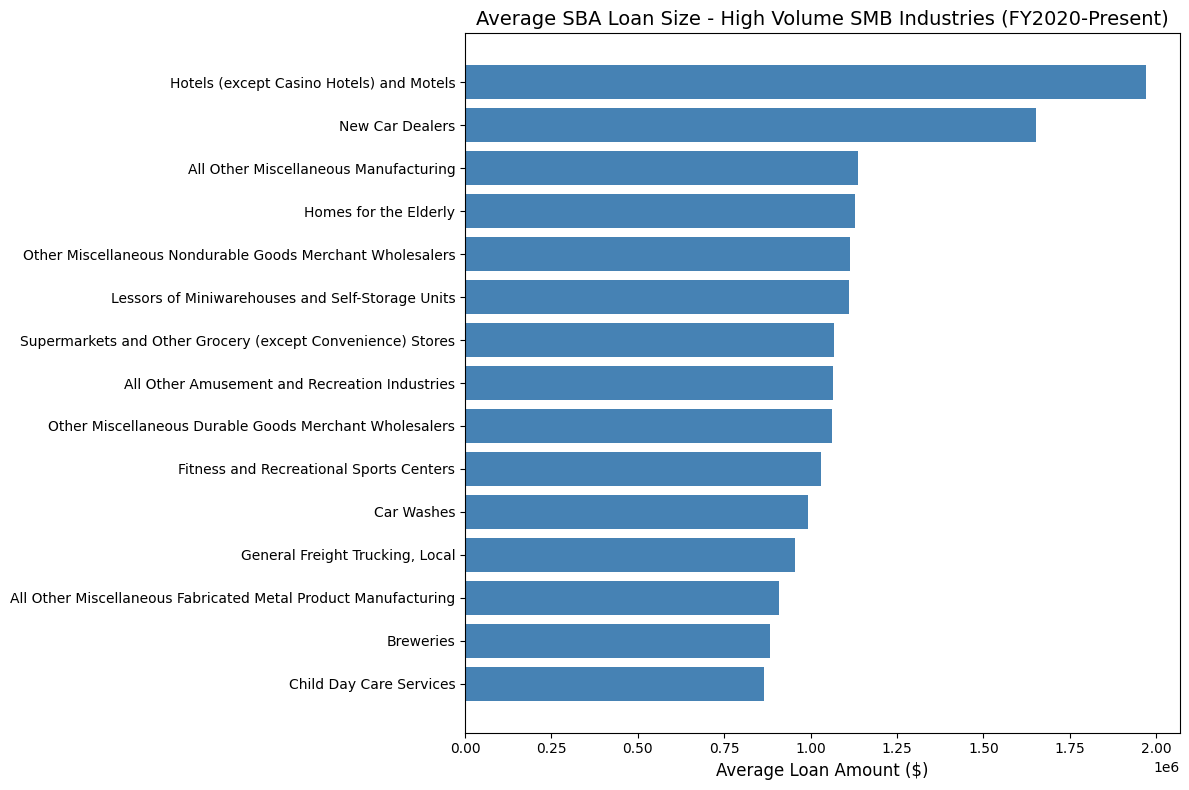

In [6]:
# Filter to industries with more than 500 loans first
industry_counts = sba_data['naicsdescription'].value_counts()
active_industries = industry_counts[industry_counts > 500].index

# Average loan size for only those active industries
avg_loan_filtered = sba_data[sba_data['naicsdescription'].isin(active_industries)].groupby('naicsdescription')['grossapproval'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
plt.barh(avg_loan_filtered.index, avg_loan_filtered.values, color='steelblue')
plt.title('Average SBA Loan Size - High Volume SMB Industries (FY2020-Present)', fontsize=14)
plt.xlabel('Average Loan Amount ($)', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

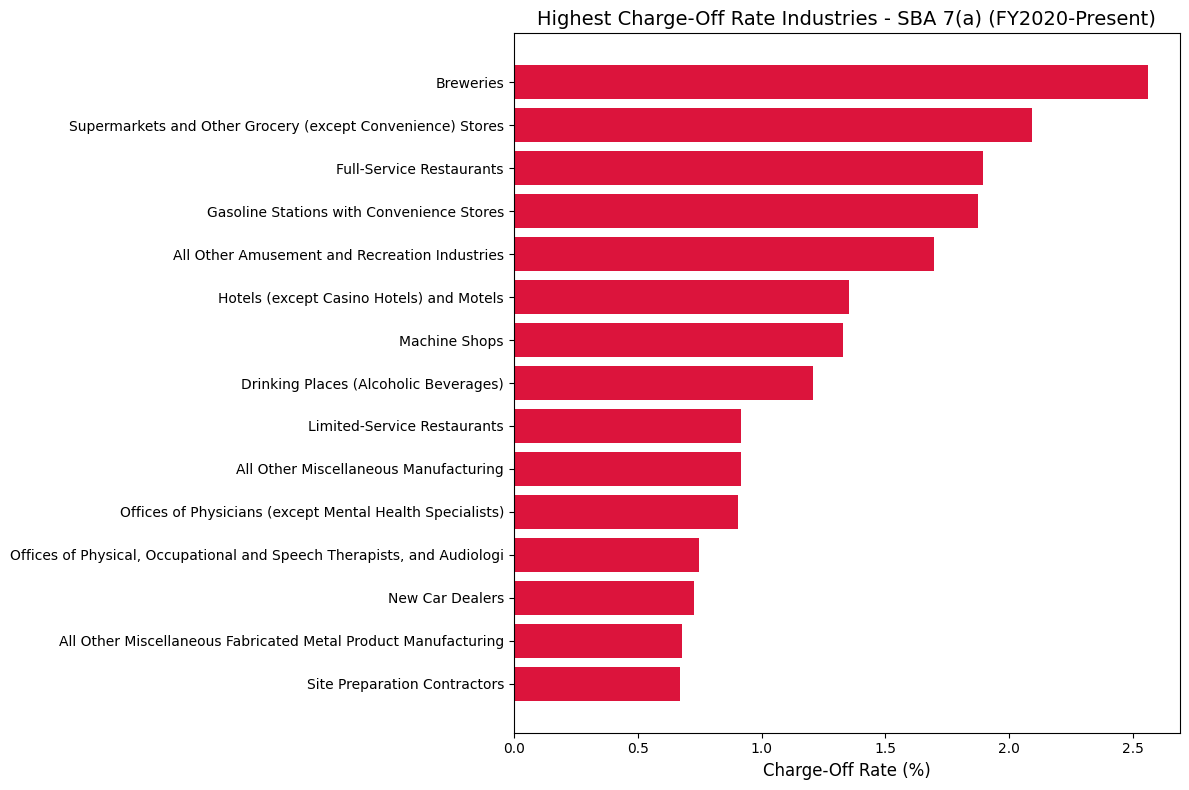

In [7]:
# Charge off rate by industry
sba_data['charged_off'] = sba_data['chargeoffdate'].notna().astype(int)

chargeoff_rate = sba_data[sba_data['naicsdescription'].isin(active_industries)].groupby('naicsdescription')['charged_off'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
plt.barh(chargeoff_rate.index, chargeoff_rate.values * 100, color='crimson')
plt.title('Highest Charge-Off Rate Industries - SBA 7(a) (FY2020-Present)', fontsize=14)
plt.xlabel('Charge-Off Rate (%)', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()